In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
sns.set(style='darkgrid')

In [168]:
data = pd.read_csv('titanic_large.csv')
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,75722,0,3,"Robinson, Master. Steven",male,55.6,2,3,600542,3.02,Q
1,80185,1,2,"Wilson, Master. Richard",male,85.0,1,0,561216,8.68,S
2,19865,1,2,"Taylor, Ms. Betty",female,NaN,0,0,589751,4.61,S
3,76700,1,3,"Smith, Mrs. Elizabeth",female,13.3,0,0,96366,5.56,S
4,92992,0,1,"Jackson, Rev. Daniel",male,55.9,0,1,416388,40.64,S


In [169]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   PassengerId  100000 non-null  int64  
 1   Survived     100000 non-null  int64  
 2   Pclass       100000 non-null  int64  
 3   Name         100000 non-null  str    
 4   Sex          100000 non-null  str    
 5   Age          80144 non-null   float64
 6   SibSp        100000 non-null  int64  
 7   Parch        100000 non-null  int64  
 8   Ticket       100000 non-null  int64  
 9   Fare         100000 non-null  float64
 10  Embarked     100000 non-null  str    
dtypes: float64(2), int64(6), str(3)
memory usage: 8.4 MB


In [170]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare
count,100000.000000,100000.000000,100000.000000,80144.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,0.396190,2.349460,31.731833,0.601000,0.398230,505207.036760,16.437273
std,28867.657797,0.489107,0.791558,18.985651,0.776315,0.631036,285402.595345,23.823469
min,1.000000,0.000000,1.000000,0.400000,0.000000,0.000000,10009.000000,0.000000
25%,25000.750000,0.000000,2.000000,16.100000,0.000000,0.000000,258419.250000,3.970000
50%,50000.500000,0.000000,3.000000,30.800000,0.000000,0.000000,505116.500000,7.500000
75%,75000.250000,1.000000,3.000000,44.225000,1.000000,1.000000,751605.500000,17.950000
max,100000.000000,1.000000,3.000000,85.000000,6.000000,6.000000,999999.000000,348.910000


In [171]:
data.isnull().sum()

PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
Age            19856
SibSp              0
Parch              0
Ticket             0
Fare               0
Embarked           0
dtype: int64

In [172]:
data['Age']

0        55.6
1        85.0
2         NaN
3        13.3
4        55.9
         ... 
99995    32.0
99996    25.5
99997     NaN
99998    32.8
99999    27.0
Name: Age, Length: 100000, dtype: float64

In [173]:
data = data.dropna(subset='Age')
data['Age'] = data['Age'].astype(int)
data['Age']

0        55
1        85
3        13
4        55
5        66
         ..
99994    38
99995    32
99996    25
99998    32
99999    27
Name: Age, Length: 80144, dtype: int64

In [174]:
data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

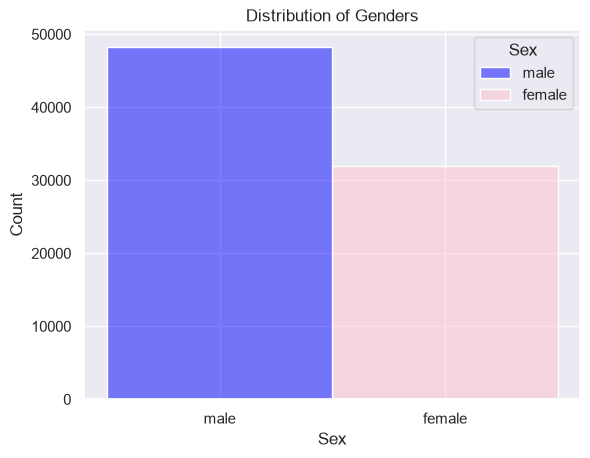

In [175]:
sns.histplot(data=data, x="Sex", hue="Sex", palette=["blue", "pink"])
plt.title("Distribution of Genders")
plt.show()

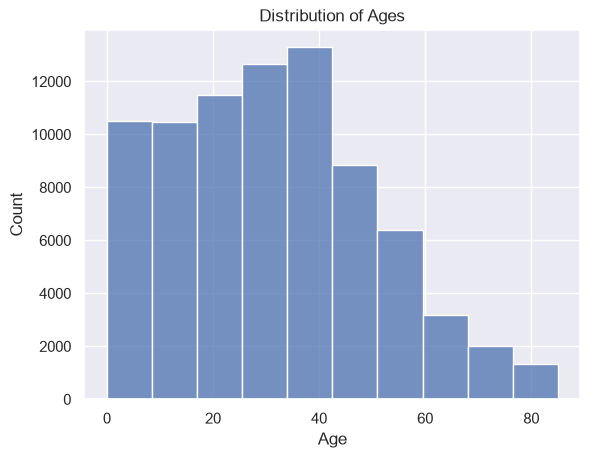

In [176]:
sns.histplot(data=data, x="Age",bins=10)
plt.title("Distribution of Ages")
plt.show()

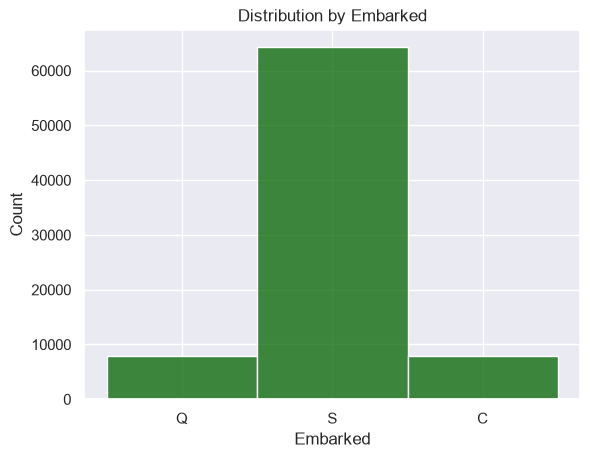

In [177]:
sns.histplot(data=data, x="Embarked",bins=10, color = 'darkgreen')
plt.title("Distribution by Embarked")
plt.show()

Pclass
3    43934
2    20171
1    16039
Name: count, dtype: int64


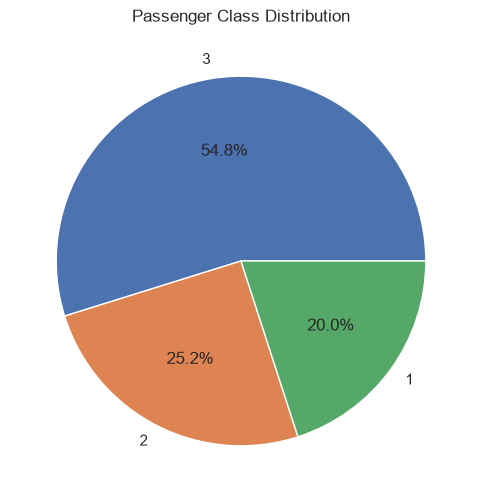

In [178]:
pclass_counts = data['Pclass'].value_counts()
print(pclass_counts)
plt.figure(figsize=(6, 6))
plt.pie(pclass_counts, autopct='%1.1f%%', labels=pclass_counts.index)
plt.title('Passenger Class Distribution')
plt.show()

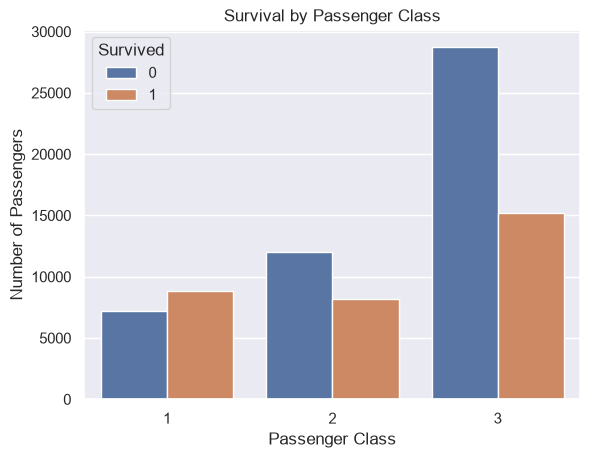

In [179]:
sns.countplot(x=data['Pclass'], hue=data['Survived'])
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.title('Survival by Passenger Class')
plt.show()

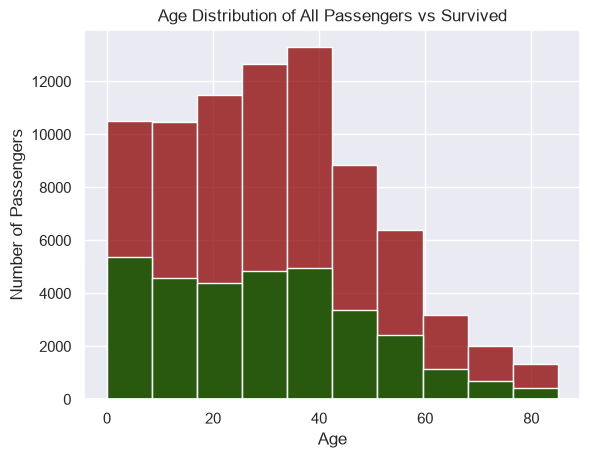

In [180]:
sns.histplot(x=data['Age'],bins=10,color = 'darkred')

survived = data[data['Survived'] == 1]
sns.histplot(x=survived['Age'],bins=10,color = 'darkgreen')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.title('Age Distribution of All Passengers vs Survived')
plt.show()



In [181]:
data.select_dtypes(include='number').keys()

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare'],
      dtype='str')

In [182]:
num_featrues = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr = data[num_featrues].corr()
corr

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.154193,-0.081197,-0.033467,0.016504,0.112424
Pclass,-0.154193,1.000000,-0.005977,-0.001708,-0.000658,-0.666396
Age,-0.081197,-0.005977,1.000000,-0.002303,-0.004382,0.002453
SibSp,-0.033467,-0.001708,-0.002303,1.000000,-0.003586,0.002143
Parch,0.016504,-0.000658,-0.004382,-0.003586,1.000000,-0.004392
Fare,0.112424,-0.666396,0.002453,0.002143,-0.004392,1.000000


Text(0.5, 1.0, 'Correlation Heatmap')

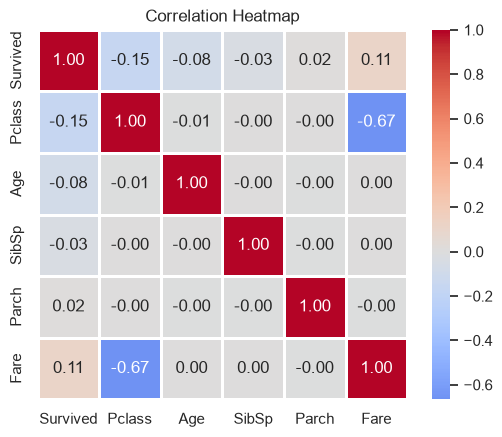

In [183]:
sns.heatmap(corr, annot=True, fmt='0.2f', cmap='coolwarm', center=0, linewidths=2, square= True)
plt.title('Correlation Heatmap')

In [184]:
data_model = data.copy()
data_model.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,75722,0,3,"Robinson, Master. Steven",male,55,2,3,600542,3.02,Q
1,80185,1,2,"Wilson, Master. Richard",male,85,1,0,561216,8.68,S
3,76700,1,3,"Smith, Mrs. Elizabeth",female,13,0,0,96366,5.56,S
4,92992,0,1,"Jackson, Rev. Daniel",male,55,0,1,416388,40.64,S
5,76435,1,3,"Garcia, Dr. Patricia",female,66,1,0,666984,12.73,S


In [185]:
data_model['Sex']

0          male
1          male
3        female
4          male
5        female
          ...  
99994    female
99995      male
99996      male
99998      male
99999    female
Name: Sex, Length: 80144, dtype: str

In [186]:
mapping = {'male': 0, 'female': 1}
encoder_arr = data_model['Sex'].map(mapping)
encoder_df = pd.DataFrame(encoder_arr.values, index=data_model.index,columns=['Sex'])
data_model['Sex'] = encoder_df
data_model['Sex']

0        0
1        0
3        1
4        0
5        1
        ..
99994    1
99995    0
99996    0
99998    0
99999    1
Name: Sex, Length: 80144, dtype: int64

In [187]:
print(data_model['Embarked'].value_counts())
data_model['Embarked']

Embarked
S    64264
C     7961
Q     7919
Name: count, dtype: int64


0        Q
1        S
3        S
4        S
5        S
        ..
99994    S
99995    S
99996    S
99998    C
99999    S
Name: Embarked, Length: 80144, dtype: str

In [188]:
mapping = {'S': 0, 'C': 1, 'Q': 2}
data_model['Embarked'] = data_model['Embarked'].map(mapping)
data_model['Embarked']

0        2
1        0
3        0
4        0
5        0
        ..
99994    0
99995    0
99996    0
99998    1
99999    0
Name: Embarked, Length: 80144, dtype: int64

In [189]:
data_model.select_dtypes(include='number').keys()

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Embarked'],
      dtype='str')

In [190]:
features = ['Survived', 'Sex', 'Age', 'SibSp', 'Parch', 'Pclass', 'Embarked']
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data_model[features])
data_scaled_df = pd.DataFrame(data_scaled, columns=features)
data_scaled_df

,Survived,Sex,Age,SibSp,Parch,Pclass,Embarked
0,0.0,0.0,0.647059,0.333333,0.500000,1.0,1.0
1,1.0,0.0,1.000000,0.166667,0.000000,0.5,0.0
2,1.0,1.0,0.152941,0.000000,0.000000,1.0,0.0
3,0.0,0.0,0.647059,0.000000,0.166667,0.0,0.0
4,1.0,1.0,0.776471,0.166667,0.000000,1.0,0.0
...,...,...,...,...,...,...,...
80139,1.0,1.0,0.447059,0.000000,0.166667,0.0,0.0
80140,0.0,0.0,0.376471,0.166667,0.166667,1.0,0.0
80141,0.0,0.0,0.294118,0.000000,0.000000,1.0,0.0
80142,0.0,0.0,0.376471,0.000000,0.166667,1.0,0.5


In [191]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split

x = data_scaled_df[['Age','Sex','Pclass','SibSp','Parch', 'Survived','Embarked']]
y = data_model['Fare']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) 
lm = LinearRegression()
lm.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ -0.36, -0.31,-39.84,..., -1.31, 0.52, -0.23]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['Age','Sex','Pclass',...,'Parch','Survived','Embarked']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,43.46
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,7


In [192]:
y_pred = lm.predict(x_test)

R2 = r2_score(y_test, y_pred)
MSE = mean_absolute_error(y_test, y_pred)
RMSE = root_mean_squared_error(y_test, y_pred)
print(f"R^2 = {R2}")
print(f"mean absolute error = {MSE}")
print(f"root mean squared error = {RMSE}")

R^2 = 0.43728926211549757
mean absolute error = 9.712432634280832
root mean squared error = 17.906307591224405


Text(0.5, 1.0, 'Actual vs Predicted Fare')

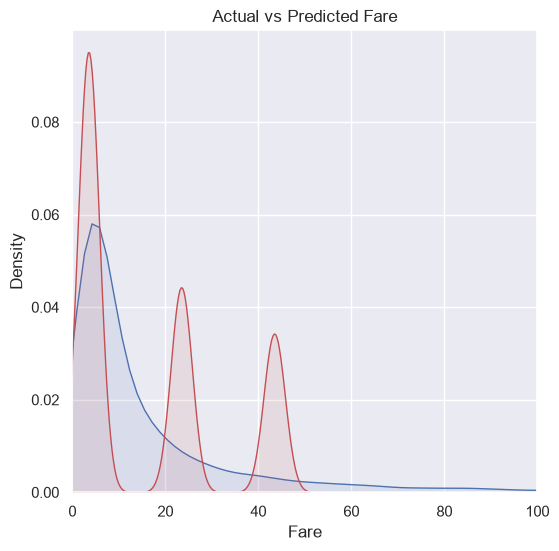

In [193]:
plt.figure(figsize=(6,6))
sns.kdeplot(y_test, fill=True, label= 'Actual',alpha=0.1)
sns.kdeplot(y_pred, fill=True, label= 'Predicted',alpha=0.1, color='r')
plt.xlim(0, 100)
plt.title('Actual vs Predicted Fare')

# Titanic Data Analysis — Documentation

## Overview
This notebook loads the Titanic passenger dataset (`titanic_large.csv`), cleans it, explores it visually, and builds a simple linear regression model to predict passenger class (`Fare`) from other passenger attributes.

## 1. Setup
Imports `pandas`, `numpy`, `matplotlib`, `seaborn`, and `sklearn` preprocessing tools (`LabelEncoder`, `MinMaxScaler`). Seaborn is set to the `darkgrid` style.

## 2. Load & Inspect Data
- Reads `titanic_large.csv` into `data` and previews it with `.head()`.
- `.info()` and `.describe()` summarize column types and basic statistics.
- `.isnull().sum()` checks for missing values in every column.

## 3. Clean Data
- Rows with a missing `Age` are dropped.
- `Age` is converted from float to integer.
- A second `.isnull().sum()` confirms no missing values remain in `Age`.

## 4. Exploratory Visualizations
- **Gender distribution** — histogram of `Sex`.
- **Age distribution** — histogram of `Age` (10 bins).
- **Embarked distribution** — histogram of `Embarked` port.
- **Passenger class breakdown** — pie chart of `Pclass` counts.
- **Survival by class** — count plot of `Pclass` split by `Survived`.
- **Age vs. survival** — overlaid histograms comparing the age distribution of all passengers against survivors.

## 5. Correlation Analysis
- Selects numeric features (`Survived`, `Pclass`, `Age`, `SibSp`, `Parch`, `Fare`), computes their correlation matrix, and displays it as an annotated heatmap.

## 6. Feature Engineering (for modeling)
A copy of the cleaned data (`data_model`) is prepared for machine learning:
- `Sex` is mapped to numbers: `male → 0`, `female → 1`.
- `Embarked` is mapped to numbers: `S → 0`, `C → 1`, `Q → 2`.
- Relevant numeric features (`Survived`, `Sex`, `Age`, `SibSp`, `Parch`, `Pclass`, `Embarked`) are scaled to a 0–1 range using `MinMaxScaler`.

## 7. Model: Predicting Passenger Class
- **Inputs (X):** `Age`, `Sex`, `Pclass`, `SibSp`, `Parch`, `Survived`, `Embarked` (all scaled).
- **Target (y):** `Fare` (unscaled).
- Data is split 80/20 into train/test sets (`random_state=42`).
- A `LinearRegression` model is trained on the training set.

## 8. Model Evaluation
Predictions are made on the test set and evaluated with:
- **R²** — how much variance in `Pclass` is explained by the model.
- **MAE** (mean absolute error)
- **RMSE** (root mean squared error)

A KDE (density) plot compares the distribution of actual vs. predicted `Fare` values, limited to the 0-100,000 range.